In [1]:
# demos/demo_setup.py
import torch, numpy as np

from nerflab.camera.camera import Camera, Intrinsics
from nerflab.camera.transforms import look_at
from nerflab.world.geometry import World, Box, Sphere
from nerflab.viz.viz_world import plot_world   # <- your new function

def make_world() -> World:
    # Adjust constructors if your world API differs
    shapes = [
        Box(center=[0.0, 0.0, 0.0], size=[2.0, 0.2, 2.0]),      # "floor" slab
        Sphere(center=[0.0, 0.25, -1.0], radius=0.35),          # small ball
        Box(center=[0.7, 0.2, -0.3], size=[0.3, 0.4, 0.3]),     # small box
    ]
    return World(shapes=shapes)

def make_intrinsics(W=320, H=240, fx=450.0, fy=450.0) -> Intrinsics:
    return Intrinsics(fx=fx, fy=fy, width=W, height=H)

def ring_poses(n=4, radius=3.5, height=1.0, target=(0.0, 0.2, -0.5)) -> torch.Tensor:
    """Return (B,4,4) poses around a ring looking at target."""
    B = n
    eyes = []
    for k in range(n):
        theta = 2 * np.pi * (k / n)
        x = radius * np.cos(theta)
        z = radius * np.sin(theta)
        eyes.append([x, height, z])
    Hs = [look_at(torch.tensor(e, dtype=torch.float32),
                  torch.tensor(target, dtype=torch.float32),
                  torch.tensor([0.0, 1.0, 0.0], dtype=torch.float32))
          for e in eyes]
    return torch.stack(Hs, dim=0)  # (B,4,4)


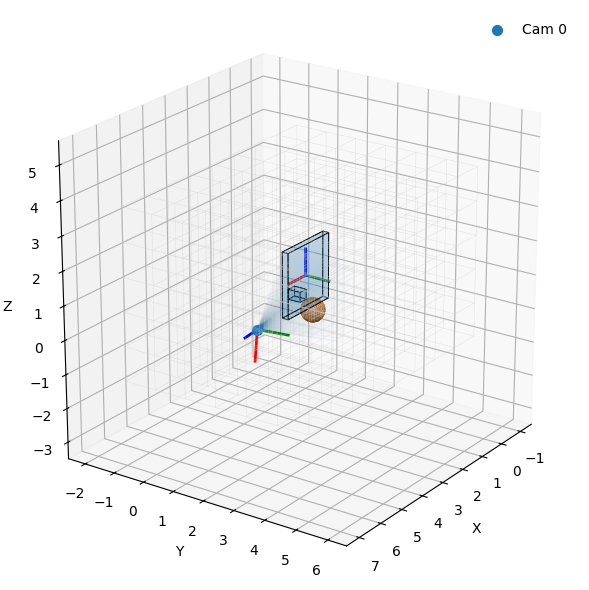

In [2]:
world = make_world()
intr  = make_intrinsics(W=320, H=240, fx=500, fy=500)

# Use the first pose from a ring as a single (4x4) camera
H_wc_batched = ring_poses(n=1, radius=4.0, height=1.2)  # (1,4,4)
H_wc = H_wc_batched[0]                                  # (4,4)

cam = Camera(H_wc, intr=intr, t_bounds=(0.2, 4.5), n_points_per_ray=32)

# Plot: world + camera pose + rays (no samples)
plot_world(
    world,
    cameras=cam,
    draw_rays=True,
    ray_mode="lines",
    ray_step=12,               # stride pixels to keep it light
    draw_samples=False,        # no sampled points this time
    grid_lines=True,
)


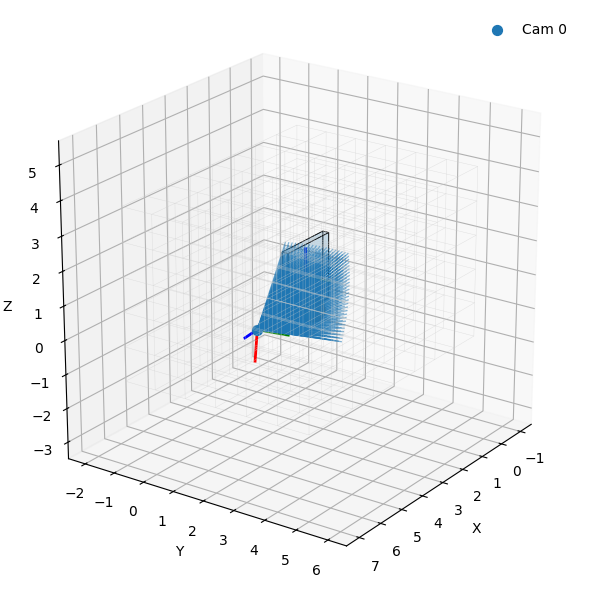

In [3]:
plot_world(
    world, cameras=cam,
    draw_rays=True, ray_mode="lines", ray_step=12,
    draw_samples=False, grid_lines=True,
    # ensure visibility:
    shape_face_alpha=0.12, shape_edge_alpha=0.75,
    ray_alpha=0.55, ray_linewidth=0.9,
)

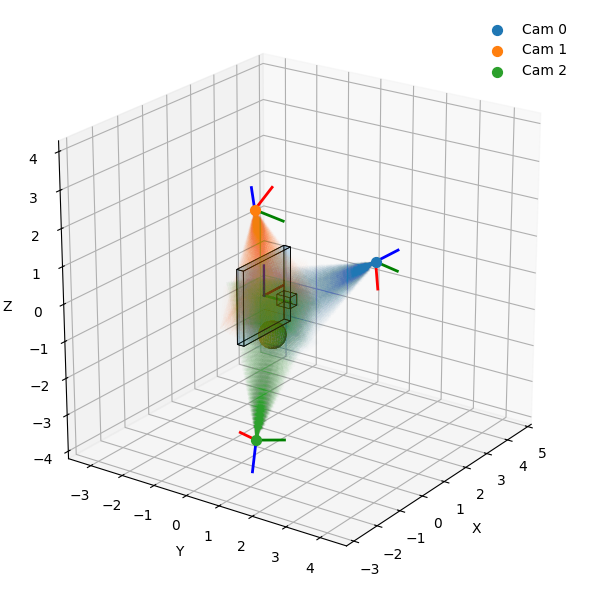

In [4]:
# demos/demo_mixed_cameras_external_points.py

world = make_world()
intr  = make_intrinsics(W=240, H=180, fx=420, fy=420)

# Batched camera (B=3)
H_wc_batch = ring_poses(n=3, radius=3.5, height=1.0)
camB = Camera(H_wc_batch, intr=intr, t_bounds=(0.3, 4.0), n_points_per_ray=36)

# A second single camera at a different height
H_wc_single = ring_poses(n=1, radius=3.2, height=1.6)[0]
camS = Camera(H_wc_single, intr=intr, t_bounds=(0.3, 4.0), n_points_per_ray=36)

# Generate a per-pose external point cloud (B,R,N,3) from camB once,
# then reuse it as "external_points" so plot_scene *doesn't* resample.
O, D = camB.get_rays_sampled(frame="world", step=16, normalize=True)   # (B,R,3)
t, dlt, pts = camB.sample_along_rays(O, D, deterministic=True) # (B,R,N), (B,R,N), (B,R,N,3)

# Plot: batched cam with quivers + external points, plus single cam with rays
plot_world(
    world,
    cameras=camB,
    cam_indices="all",
    draw_rays=True,
    ray_mode="quiver",
    external_points=pts,   # shape (B,R,N,3) — overrides draw_samples for those cams
    external_point_size=3.0,
    grid_lines=False,
    invert_axes=("x",),    # optional flip for OpenGL-like feel
)


In [5]:
print(O.shape)

torch.Size([3, 180, 3])


In [6]:
print(pts.shape)

torch.Size([3, 180, 36, 3])


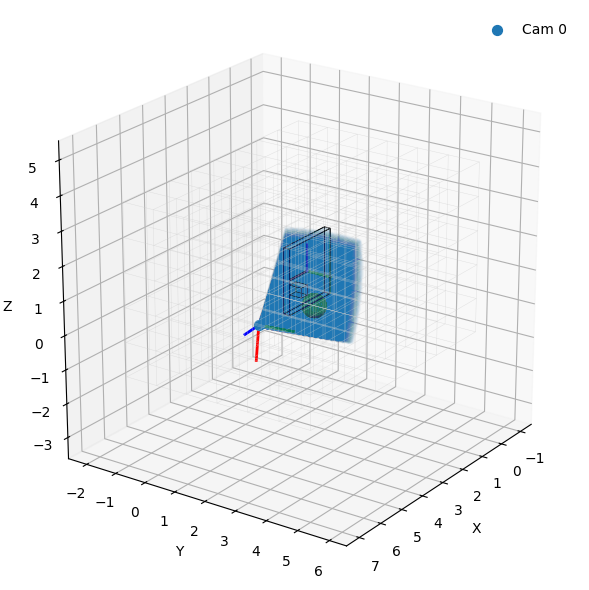

In [7]:
# demos/demo_dense_cloud_only.py

world = make_world()
intr  = make_intrinsics(W=400, H=300, fx=600, fy=600)
H_wc  = ring_poses(n=1, radius=4.0, height=1.2)[0]

cam = Camera(H_wc, intr=intr, t_bounds=(0.2, 5.0), n_points_per_ray=64)

# Precompute samples densely, then plot only the sampled points
O, D = cam.get_rays(frame="world", step=4, normalize=True)    # (R,3)
t, dlt, pts = cam.sample_along_rays(O, D, deterministic=True) # (R,N),(R,N),(R,N,3)

plot_world(
    world,
    cameras=cam,
    external_points=pts,        # (R,N,3)
    external_point_size=2.5,
    draw_rays=False,            # rays disabled
    grid_lines=True,
)


In [8]:
# demos/demo_assertions.py

intr = make_intrinsics(W=64, H=48)
H = ring_poses(n=2, radius=2.5, height=1.0)
cam = Camera(H, intr=intr, t_bounds=(0.3, 3.0), n_points_per_ray=16)

O, D = cam.get_rays(frame="world", step=2, normalize=True)  # (B,R,3)
assert O.ndim == 3 and D.shape == O.shape and O.shape[-1] == 3
B, R, _ = O.shape

# explicit indices sampling
idx = torch.randint(R, (B, 50))
O2, D2 = cam.get_rays_sampled(indices=idx)
assert O2.shape == (B, 50, 3) and D2.shape == (B, 50, 3)

# along-ray sampling
t, dlt, pts = cam.sample_along_rays(O2, D2, deterministic=True)
assert t.shape[:2] == (B, 50) and pts.shape == (B, 50, cam.n_points_per_ray, 3)
print("All shape checks passed.")


All shape checks passed.
